# Figure 3/S5/S7/S8 iPSC graphics

In [40]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve
import re
from matplotlib.patches import Patch

# OR gate

## Load df_OR

In [28]:
output_path_Figure3 = rd.rootdir/'output'/'Figure_3'
output_path_FigureS7 = rd.rootdir/'output'/'Figure_S7'
output_path_FigureS8 = rd.rootdir/'output'/'Figure_S8'
output_path_FigureS5 = rd.rootdir/'output'/'Figure_S5'

In [4]:
# Directories
figpath_OR = './figures/2025.11.11_ABdata-iPSC-DASIT/OR/'
df_ORdir = rd.datadir /'data'/'attune'/ 'Albert'/'DesNb' / "OR" / "export_singlets"

# Store all df_OR in list of dfs which will be converted to df at end
df_OR = list()
# ctrl_df_OR = list()
files = Path(df_ORdir).glob('*.csv')

# df_OR path
cache_path = df_ORdir / 'df_OR.gzip'

if cache_path.exists():

    df_OR = pd.read_parquet(cache_path)

else: 

    for i, file in enumerate(files):

        print(file.name)

        # Extract metadf_OR from csv title
        match = re.search(
            'export_(?P<cond>.+)_(?P<select>.+)_(?P<rep>\d)_(?P<subsetName>.+).csv', file.name)
        
        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        select = match.group('select')
        rep = match.group('rep')
        subsetName = match.group('subsetName')

        # Load as df and note header is on 0th row
        flow_df = pd.read_csv(file, header=0)

        # Update columns in df with metadf_OR from file name
        flow_df['cond'] = cond
        flow_df['select'] = select
        flow_df['rep'] = int(rep)
        flow_df['subsetName'] = subsetName
        
        df_OR.append(flow_df)

    # Convert list of dfs into single df
    df_OR = pd.concat(df_OR, ignore_index=True)

    # Shorten df
    channel_list = ['FSC-A', 'SSC-A','mGreenLantern-A','mTagBFP2-A','mScarlet-A', 'cond', 'select', 'rep', 'subsetName']
    df_OR = df_OR.loc[:, channel_list]
    # Rename FP channels
    df_OR.rename(columns={'mGreenLantern-A': 'EGFP-A', 'mTagBFP2-A':'EBFP2-A'}, inplace=True)

    # Save shortened df
    df_OR.to_parquet(rd.outfile(cache_path))


<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\124814161.py:25: SyntaxWarning: invalid escape sequence '\d'
  'export_(?P<cond>.+)_(?P<select>.+)_(?P<rep>\d)_(?P<subsetName>.+).csv', file.name)


In [5]:
display(df_OR)

,FSC-A,SSC-A,EGFP-A,EBFP2-A,mScarlet-A,cond,select,rep,subsetName
0,518261.0,104055.0,85462,280,-8,EGFP,Post,3,Singlets
1,564071.0,168504.0,233679,398,54,EGFP,Post,3,Singlets
2,451462.0,165061.0,241638,636,224,EGFP,Post,3,Singlets
3,646039.0,379509.0,101420,450,469,EGFP,Post,3,Singlets
4,595968.0,260280.0,358049,1027,206,EGFP,Post,3,Singlets
...,...,...,...,...,...,...,...,...,...
292368,431487.0,283091.0,220,297,60,EGFP,Pre,2,Singlets
292369,527709.0,454167.0,310,647,382,EGFP,Pre,2,Singlets
292370,582518.0,482647.0,482,924,348,EGFP,Pre,2,Singlets
292371,425402.0,284044.0,242,315,329,EGFP,Pre,2,Singlets


## EGFP gate

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

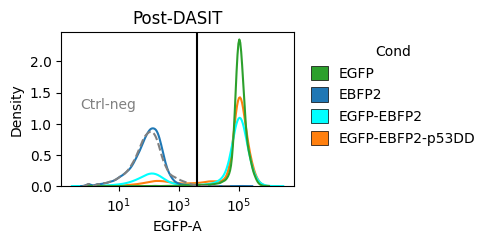

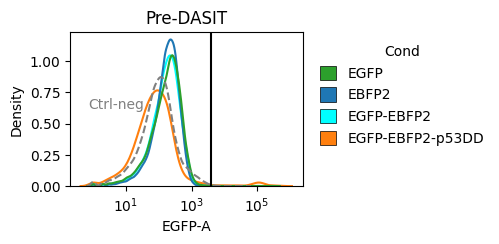

In [16]:
# Threshold for transfect
EGFP_A_thresh = 4e3

# Plotting parameters
x = 'EGFP-A'
hue = 'cond'
hue_order = ["EGFP", "EBFP2", "EGFP-EBFP2", "EGFP-EBFP2-p53DD",]
palette = {
    'EGFP': 'tab:green',
    'EBFP2': 'tab:blue',
    "EGFP-EBFP2": "cyan",
    "EGFP-EBFP2-p53DD": "tab:orange",
}


# Plot
for select in df_OR.select.unique():
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_OR[(df_OR[x]>0) & (df_OR['select']==select)],
        ax=ax, x=x, hue=hue, hue_order=hue_order,
        common_norm=False, log_scale=(True, False), palette=palette,
        fill=False)

        # Plot ctrl-neg
        sns.kdeplot(data=df_OR.loc[(df_OR['cond'] == 'Ctrl-neg') & (df_OR[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
        ax.annotate('Ctrl-neg', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(EGFP_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{select}-DASIT')

        # Remove existing legend
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Create legend handles using the palette colors
        legend_handles = [
            Patch(
                facecolor=palette[label],
                edgecolor='black',
                linewidth=0.5,
                label=label
            )
            for label in hue_order
        ]

        ax.legend(
            handles=legend_handles,
            title='Cond',
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            frameon=False,
            handlelength=1.2,
            handleheight=1.2
        )

    # plt.savefig(figpath_OR + f'dist-EGFP_{select}-DASIT.svg', bbox_inches='tight')

## EBFP2 gate

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

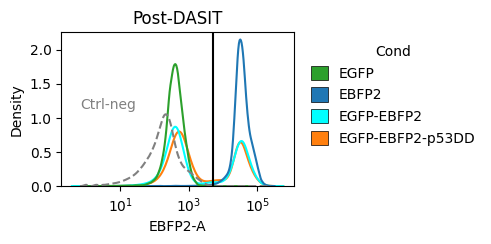

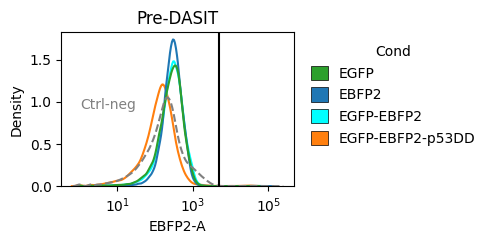

In [18]:
# Threshold for transfect
EBFP2_A_thresh = 5e3

# Plotting parameters
x = 'EBFP2-A'
hue = 'cond'
hue_order = ["EGFP", "EBFP2", "EGFP-EBFP2", "EGFP-EBFP2-p53DD",]
palette = {
    'EGFP': 'tab:green',
    'EBFP2': 'tab:blue',
    "EGFP-EBFP2": "cyan",
    "EGFP-EBFP2-p53DD": "tab:orange",
}


# Plot
for select in df_OR.select.unique():
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_OR[(df_OR[x]>0) & (df_OR['select']==select)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False), palette=palette,
                fill=False)

        # Plot ctrl-neg
        sns.kdeplot(data=df_OR.loc[(df_OR['cond'] == 'Ctrl-neg') & (df_OR[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('Ctrl-neg', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(EBFP2_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{select}-DASIT')
    
        # Remove existing legend
        if ax.get_legend() is not None:
                ax.get_legend().remove()

        # Create legend handles using the palette colors
        legend_handles = [
                Patch(
                facecolor=palette[label],
                edgecolor='black',
                linewidth=0.5,
                label=label
                )
                for label in hue_order
        ]

        ax.legend(
                handles=legend_handles,
                title='Cond',
                loc='upper left',
                bbox_to_anchor=(1.02, 1),
                frameon=False,
                handlelength=1.2,
                handleheight=1.2
        )

    # plt.savefig(figpath_OR + f'dist-EBFP2_{select}-DASIT.svg', bbox_inches='tight')

## Figure S7 (Final plots for joint distributions)

**Figure S7B, post-DASIT**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\421537622.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df_OR_ctrl['select'] = 'Post'
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', Tr

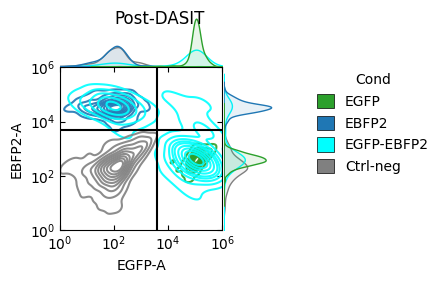

In [29]:
# General plotting params
x = "EGFP-A"
y = "EBFP2-A"

hue = 'cond'
hue_order = ["EGFP", "EBFP2", "EGFP-EBFP2", "Ctrl-neg"]
# hue_order = ["EGFP"]
palette = {
    'EGFP': 'tab:green',
    'EBFP2': 'tab:blue',
    "EGFP-EBFP2": "cyan",
    "EGFP-EBFP2-p53DD": "tab:orange",
    "Ctrl-neg": 'grey',
}

# Downsample df_OR for faster
small_df_OR = df_OR[(df_OR[x]>0) & (df_OR[y]>0) & (df_OR['cond'].isin(hue_order))]
small_df_OR = small_df_OR.groupby(['cond', 'select']).sample(n=1000)

# Add ctrl-neg back in
small_df_OR_ctrl = small_df_OR.loc[small_df_OR.cond == 'Ctrl-neg']
small_df_OR_ctrl['select'] = 'Post'
small_df_OR = pd.concat([small_df_OR, small_df_OR_ctrl], ignore_index=True)

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = (1, 1e6)
xlim = (1, 1e6)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
select = "Post"
# select = "Pre"
sns.kdeplot(
    ax=ax_scatter,
    data=small_df_OR[(small_df_OR['select']==select)],
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_df_OR[(small_df_OR['select']==select)], x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=True,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_df_OR[(small_df_OR['select']==select)],y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# Remove any automatically generated legends
for a in [ax_scatter, ax_histx, ax_histy]:
    if a.get_legend() is not None:
        a.get_legend().remove()

# Create legend handles
legend_handles = [
    Patch(
        facecolor=palette[label],
        edgecolor='black',
        linewidth=0.5,
        label=label
    )
    for label in hue_order
]

# Leave room on the right for the legend
fig.subplots_adjust(right=0.82)

# Add legend outside the plot
ax_scatter.legend(
    handles=legend_handles,
    title='Cond',
    loc='upper left',
    bbox_to_anchor=(1.55, 1.0),
    frameon=False,
    borderaxespad=0,
    handlelength=1.2,
    handleheight=1.2
)

# Threshold
ax_scatter.axvline(EGFP_A_thresh, 0, 1, color='black')
ax_scatter.axhline(EBFP2_A_thresh, 0, 1, color='black')

plt.suptitle(f'{select}-DASIT')

fig.tight_layout()  # Helps improve white spacing
plottitle = f'Figure_S7B_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')

**Figure S7B, pre-DASIT**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\2379367992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df_OR_ctrl['select'] = 'Pre'
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', Tr

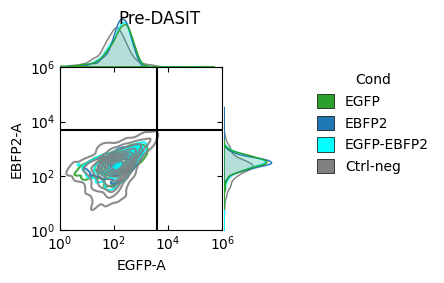

In [30]:
# General plotting params
x = "EGFP-A"
y = "EBFP2-A"

hue = 'cond'
hue_order = ["EGFP", "EBFP2", "EGFP-EBFP2", "Ctrl-neg"]
# hue_order = ["EGFP"]
palette = {
    'EGFP': 'tab:green',
    'EBFP2': 'tab:blue',
    "EGFP-EBFP2": "cyan",
    "EGFP-EBFP2-p53DD": "tab:orange",
    "Ctrl-neg": 'grey',
}

# Downsample df_OR for faster
small_df_OR = df_OR[(df_OR[x]>0) & (df_OR[y]>0) & (df_OR['cond'].isin(hue_order))]
small_df_OR = small_df_OR.groupby(['cond', 'select']).sample(n=1000)

# Add ctrl-neg back in
small_df_OR_ctrl = small_df_OR.loc[small_df_OR.cond == 'Ctrl-neg']
small_df_OR_ctrl['select'] = 'Pre'
small_df_OR = pd.concat([small_df_OR, small_df_OR_ctrl], ignore_index=True)

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = (1, 1e6)
xlim = (1, 1e6)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
select = "Pre"

sns.kdeplot(
    ax=ax_scatter,
    data=small_df_OR[(small_df_OR['select']==select)],
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_df_OR[(small_df_OR['select']==select)], x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=True,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_df_OR[(small_df_OR['select']==select)],y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# Remove any automatically generated legends
for a in [ax_scatter, ax_histx, ax_histy]:
    if a.get_legend() is not None:
        a.get_legend().remove()

# Create legend handles
legend_handles = [
    Patch(
        facecolor=palette[label],
        edgecolor='black',
        linewidth=0.5,
        label=label
    )
    for label in hue_order
]

# Leave room on the right for the legend
fig.subplots_adjust(right=0.82)

# Add legend outside the plot
ax_scatter.legend(
    handles=legend_handles,
    title='Cond',
    loc='upper left',
    bbox_to_anchor=(1.55, 1.0),
    frameon=False,
    borderaxespad=0,
    handlelength=1.2,
    handleheight=1.2
)

# Threshold
ax_scatter.axvline(EGFP_A_thresh, 0, 1, color='black')
ax_scatter.axhline(EBFP2_A_thresh, 0, 1, color='black')

plt.suptitle(f'{select}-DASIT')

fig.tight_layout()  # Helps improve white spacing
plottitle = f'Figure_S7B_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')

## Figure S7 (Final plots for single distributions)

**Figure S7A, plots 3 and 4**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

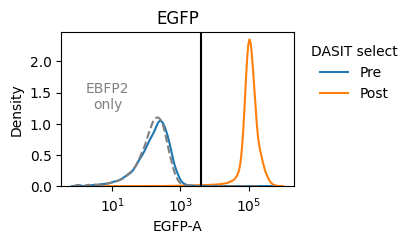

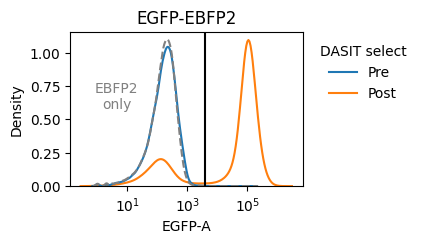

In [69]:
# Plotting parameters
x = 'EGFP-A'
hue = 'select'
hue_order = ["Pre", "Post"]

# Plot
for cond in ["EGFP", "EGFP-EBFP2"]:
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_OR[(df_OR[x]>0) & (df_OR['cond']==cond)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False),
                fill=False)

        # Plot neg
        sns.kdeplot(data=df_OR.loc[(df_OR['cond'] == 'EBFP2') & (df_OR[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('EBFP2\nonly', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(EGFP_A_thresh, 0, 1, color='black')

        # Format
        # Format
        plt.title(cond)

        # Save existing Seaborn legend handles/labels
        leg = ax.get_legend()
        handles = leg.legend_handles
        labels = [text.get_text() for text in leg.get_texts()]

        # Remove existing legend
        leg.remove()

        # Recreate legend on right with line handles
        ax.legend(
                handles=handles,
                labels=labels,
                title='DASIT select',
                loc='upper left',
                bbox_to_anchor=(1.02, 1),
                frameon=False
        )

        plottitle = f'Figure_S7A_bottom_{cond}-DASIT.svg'
        plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')     

**Figure S7A, plots 1 and 2**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

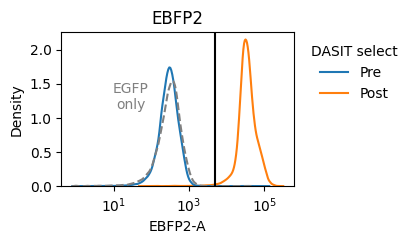

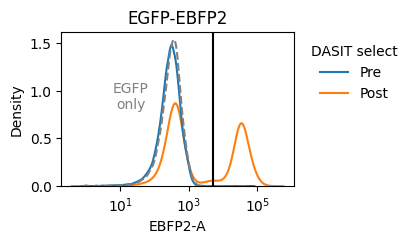

In [70]:
# Plotting parameters
x = 'EBFP2-A'
hue = 'select'
hue_order = ["Pre", "Post"]

# Plot
for cond in ["EBFP2", "EGFP-EBFP2"]:
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_OR[(df_OR[x]>0) & (df_OR['cond']==cond)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False),
                fill=False)

        # Plot neg
        sns.kdeplot(data=df_OR.loc[(df_OR['cond'] == 'EGFP') & (df_OR[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('EGFP\nonly', (0.3, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(EBFP2_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{cond}')
        # Save existing Seaborn legend handles/labels
        leg = ax.get_legend()
        handles = leg.legend_handles
        labels = [text.get_text() for text in leg.get_texts()]

        # Remove existing legend
        leg.remove()

        # Recreate legend on right with line handles
        ax.legend(
        handles=handles,
        labels=labels,
        title='DASIT select',
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=False
        )
        
        plottitle = f'Figure_S7A_top_{cond}-DASIT.svg'
        plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')     

## Figure 3 (Stacked barcharts, OR)

In [ ]:
# Categorize cells 
df_OR['EGFP_cat'] = np.where(df_OR['EGFP-A'] > EGFP_A_thresh, 'EGFP+', 'EGFP-') 
df_OR['EBFP2_cat'] = np.where(df_OR['EBFP2-A'] > EBFP2_A_thresh, 'EBFP2+', 'EBFP2-') 

df_OR.loc[(df_OR['EGFP_cat'] == 'EGFP+') & (df_OR['EBFP2_cat'] == 'EBFP2+'), 'FP_cat' ] = 'Both'
df_OR.loc[(df_OR['EGFP_cat'] == 'EGFP+') & (df_OR['EBFP2_cat'] == 'EBFP2-'), 'FP_cat' ] = 'EGFP'
df_OR.loc[(df_OR['EGFP_cat'] == 'EGFP-') & (df_OR['EBFP2_cat'] == 'EBFP2+'), 'FP_cat' ] = 'EBFP2'
df_OR.loc[(df_OR['EGFP_cat'] == 'EGFP-') & (df_OR['EBFP2_cat'] == 'EBFP2-'), 'FP_cat' ] = 'Neg'

# Get total counts and percent of GFP-H+
group = ['cond', 'select']
count_df_reps = df_OR.groupby([*group, 'rep', 'FP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
# Puts 0 if no GFP-H+ rather than dropping row
df_percent_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'rep']).transform('sum')).reset_index(name='percent')


# Remove p53DD 
df_percent_reps = df_percent_reps[df_percent_reps.cond != 'EGFP-EBFP2-p53DD']


# Collapse reps
df_percent_mean = df_percent_reps.groupby([*group, 'FP_cat']).mean().reset_index()
df_percent_sem = df_percent_reps.groupby([*group, 'FP_cat']).sem().reset_index()


**Figure 3B, post-DASIT**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\494771659.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')


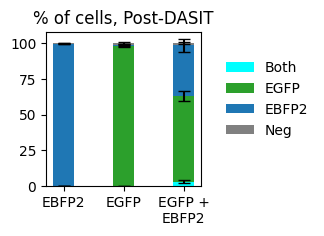

In [53]:
# Plot params
width = 0.35       # the width of the bars: can also be len(x) sequence
capsize = 4        # Capsize
label_dict = {
    'EGFP': 'EGFP',
    'EBFP2': 'EBFP2',
    "EGFP-EBFP2": "EGFP +\nEBFP2",
    "EGFP-EBFP2-p53DD":"EGFP +\nEBFP2 +\np53DD",
    "Ctrl-neg": 'Neg'
}

# Extract each mean and SEM
select = 'Post'
curr_mean = df_percent_mean[df_percent_mean.select == select]
curr_sem = df_percent_sem[df_percent_sem.select == select]
# Drop Ctrl-neg
curr_mean = curr_mean[curr_mean.cond != "Ctrl-neg"]
curr_sem = curr_sem[curr_sem.cond != "Ctrl-neg"]

FP_cat = 'Both'
labels = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'cond']
both_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
both_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'EGFP'
EGFP_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
EGFP_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'EBFP2'
EEBFP2_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
EBFP2_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'Neg'
Neg_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
Neg_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax.bar(labels, both_mean, width, yerr=both_sem, label='Both', color='cyan', capsize=capsize)
ax.bar(labels, EGFP_mean, width, yerr=EGFP_sem, bottom=both_mean, label='EGFP', color='tab:green', capsize=capsize)
ax.bar(labels, EEBFP2_mean, width, yerr=EBFP2_sem, bottom=both_mean.to_numpy()+EGFP_mean.to_numpy(), label='EBFP2', color='tab:blue', capsize=capsize)
ax.bar(labels, Neg_mean, width, yerr=Neg_sem, bottom=both_mean.to_numpy()+EGFP_mean.to_numpy()+EEBFP2_mean.to_numpy(), label='Neg', color='grey', capsize=capsize)

# # Add 100% line
# ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Rename axis labels
ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')
# ax.set_ylabel('(%)')
plt.title(f'% of cells, {select}-DASIT')
fig.legend(loc='upper right', bbox_to_anchor=(1.5, 0.8), frameon=False)


plottitle = f'Figure_S3B_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_Figure3/plottitle),bbox_inches='tight')  

**Figure 3B, pre-DASIT**

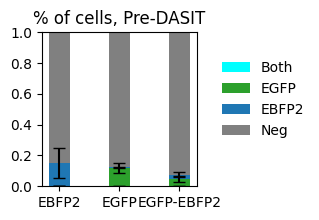

In [54]:
# Plot params
width = 0.35       # the width of the bars: can also be len(x) sequence
capsize = 4        # Capsize
label_dict = {
    'EGFP': 'EGFP',
    'EBFP2': 'EBFP2',
    "EGFP-EBFP2": "EGFP +\nEBFP2",
    "EGFP-EBFP2-p53DD":"EGFP +\nEBFP2 +\np53DD",
    "Ctrl-neg": 'Neg'
}

# Extract each mean and SEM
select = 'Pre'
curr_mean = df_percent_mean[df_percent_mean.select == select]
curr_sem = df_percent_sem[df_percent_sem.select == select]
# Drop Ctrl-neg
curr_mean = curr_mean[curr_mean.cond != "Ctrl-neg"]
curr_sem = curr_sem[curr_sem.cond != "Ctrl-neg"]

FP_cat = 'Both'
labels = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'cond']
both_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
both_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'EGFP'
EGFP_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
EGFP_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'EBFP2'
EEBFP2_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
EBFP2_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'Neg'
Neg_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
Neg_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax.bar(labels, both_mean, width, yerr=both_sem, label='Both', color='cyan', capsize=capsize)
ax.bar(labels, EGFP_mean, width, yerr=EGFP_sem, bottom=both_mean, label='EGFP', color='tab:green', capsize=capsize)
ax.bar(labels, EEBFP2_mean, width, yerr=EBFP2_sem, bottom=both_mean.to_numpy()+EGFP_mean.to_numpy(), label='EBFP2', color='tab:blue', capsize=capsize)
ax.bar(labels, Neg_mean, width, yerr=Neg_sem, bottom=both_mean.to_numpy()+EGFP_mean.to_numpy()+EEBFP2_mean.to_numpy(), label='Neg', color='grey', capsize=capsize)

# # Add 100% line
# ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Rename axis labels
# ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')
# ax.set_ylabel('(%)')
ax.set_ylim([0, 1])
plt.title(f'% of cells, {select}-DASIT')
fig.legend(loc='upper right', bbox_to_anchor=(1.5, 0.8), frameon=False)

plottitle = f'Figure_S3B_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_Figure3/plottitle),bbox_inches='tight')  

# AND gate

## Load df_AND

In [ ]:
# Directories
df_AND_dir = rd.datadir / 'data'/'attune'/'Albert'/'DesNb'/ "AND" / "export_singlets"

# Store all df_OR in list of dfs which will be converted to df at end
df_AND = list()
# ctrl_df_OR = list()
files = Path(df_AND_dir).glob('*.csv')

# df_OR path
cache_path = df_AND_dir / 'df_AND.gzip'

if cache_path.exists():

    df_AND = pd.read_parquet(cache_path)

else: 

    for i, file in enumerate(files):

        print(file.name)

        # Extract metadf_OR from csv title
        match = re.search(
            'export_(?P<cond>.+)_(?P<select>.+)_(?P<rep>\d)_(?P<subsetName>.+).csv', file.name)
        
        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        select = match.group('select')
        rep = match.group('rep')
        subsetName = match.group('subsetName')

        # if cond == mScarlet, rename
        if cond == "mScarlet": cond = 'mScarlet$^{ALFA}$'
        elif cond == "mScarlet-EBFP2": cond = 'mScarlet$^{ALFA}$-EBFP2'
        elif cond == "mScarlet-EBFP2-p53DD": cond = 'mScarlet$^{ALFA}$-EBFP2-p53DD'

        # Load as df and note header is on 0th row
        flow_df = pd.read_csv(file, header=0)

        # Update columns in df with metadf_OR from file name
        flow_df['cond'] = cond
        flow_df['select'] = select
        flow_df['rep'] = int(rep)
        flow_df['subsetName'] = subsetName
        
        df_AND.append(flow_df)

    # Convert list of dfs into single df
    df_AND = pd.concat(df_AND, ignore_index=True)

    # Shorten df
    channel_list = ['FSC-A', 'SSC-A','mGreenLantern-A','mTagBFP2-A','mScarlet-A', 'cond', 'select', 'rep', 'subsetName']
    df_AND = df_AND.loc[:, channel_list]
    # Rename FP channels
    df_AND.rename(columns={'mGreenLantern-A': 'EGFP-A', 'mTagBFP2-A':'EBFP2-A'}, inplace=True)

    # Save shortened df
    df_AND.to_parquet(rd.outfile(cache_path))


<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\3802991613.py:25: SyntaxWarning: invalid escape sequence '\d'
  'export_(?P<cond>.+)_(?P<select>.+)_(?P<rep>\d)_(?P<subsetName>.+).csv', file.name)


In [57]:
display(df_AND)

,FSC-A,SSC-A,EGFP-A,EBFP2-A,mScarlet-A,cond,select,rep,subsetName
0,740653,328760,2994,953,136398,mScarlet$^{ALFA}$,Post,2,Singlets
1,449700,280607,1354,1118,38632,mScarlet$^{ALFA}$,Post,2,Singlets
2,705522,296361,1120,564,44113,mScarlet$^{ALFA}$,Post,2,Singlets
3,517820,331314,1637,2063,48559,mScarlet$^{ALFA}$,Post,2,Singlets
4,702567,331775,1873,943,82938,mScarlet$^{ALFA}$,Post,2,Singlets
...,...,...,...,...,...,...,...,...,...
241989,376224,202892,59,634,30,mScarlet$^{ALFA}$-EBFP2-p53DD,Pre,2,Singlets
241990,547124,269962,-35,379,130,mScarlet$^{ALFA}$-EBFP2-p53DD,Pre,2,Singlets
241991,727591,522805,859,5383,120,mScarlet$^{ALFA}$-EBFP2-p53DD,Pre,2,Singlets
241992,547177,158513,147,885,244,mScarlet$^{ALFA}$-EBFP2-p53DD,Pre,2,Singlets


## Gating

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

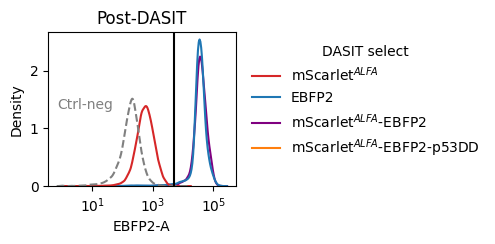

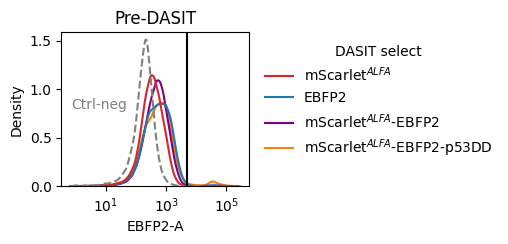

In [60]:
# Threshold for transfect
EBFP2_A_thresh = 5e3

# Plotting parameters
x = 'EBFP2-A'
hue = 'cond'
hue_order = ["mScarlet$^{ALFA}$", "EBFP2", "mScarlet$^{ALFA}$-EBFP2", "mScarlet$^{ALFA}$-EBFP2-p53DD"]
palette = {
    "mScarlet$^{ALFA}$": 'tab:red',
    'EBFP2': 'tab:blue',
    "mScarlet$^{ALFA}$-EBFP2": "purple",
    "mScarlet$^{ALFA}$-EBFP2-p53DD": "tab:orange",
    "Ctrl-neg": 'grey',
}



# Plot
for select in df_AND.select.unique():
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_AND[(df_AND[x]>0) & (df_AND['select']==select)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False), palette=palette,
                fill=False)

        # Plot ctrl-neg
        sns.kdeplot(data=df_AND.loc[(df_AND['cond'] == 'Ctrl-neg') & (df_AND[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('Ctrl-neg', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(EBFP2_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{select}-DASIT')
        # Save existing Seaborn legend handles/labels
        leg = ax.get_legend()
        handles = leg.legend_handles
        labels = [text.get_text() for text in leg.get_texts()]

        # Remove existing legend
        leg.remove()

        # Make room for legend
        fig.subplots_adjust(right=0.75)

        # Recreate legend on right with line handles
        ax.legend(
        handles=handles,
        labels=labels,
        title='DASIT select',
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=False
        )

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

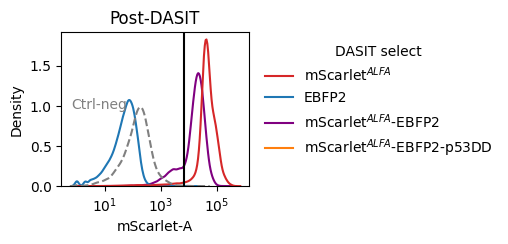

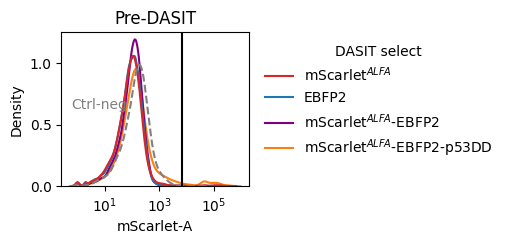

In [61]:
# Threshold for transfect
mScarlet_A_thresh = 7e3

# Plotting parameters
x = 'mScarlet-A'
hue = 'cond'
hue_order = ["mScarlet$^{ALFA}$", "EBFP2", "mScarlet$^{ALFA}$-EBFP2", "mScarlet$^{ALFA}$-EBFP2-p53DD"]
palette = {
    "mScarlet$^{ALFA}$": 'tab:red',
    'EBFP2': 'tab:blue',
    "mScarlet$^{ALFA}$-EBFP2": "purple",
    "mScarlet$^{ALFA}$-EBFP2-p53DD": "tab:orange",
    "Ctrl-neg": 'grey',
}



# Plot
for select in df_AND.select.unique():
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_AND[(df_AND[x]>0) & (df_AND['select']==select)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False), palette=palette,
                fill=False)

        # Plot ctrl-neg
        sns.kdeplot(data=df_AND.loc[(df_AND['cond'] == 'Ctrl-neg') & (df_AND[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('Ctrl-neg', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(mScarlet_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{select}-DASIT')
        # Save existing Seaborn legend handles/labels
        leg = ax.get_legend()
        handles = leg.legend_handles
        labels = [text.get_text() for text in leg.get_texts()]

        # Remove existing legend
        leg.remove()

        # Make room for legend
        fig.subplots_adjust(right=0.75)

        # Recreate legend on right with line handles
        ax.legend(
        handles=handles,
        labels=labels,
        title='DASIT select',
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=False
        )

## Figure S7 (Final plots for joint distribution AND)

**Figure S7D, post-DASIT**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs

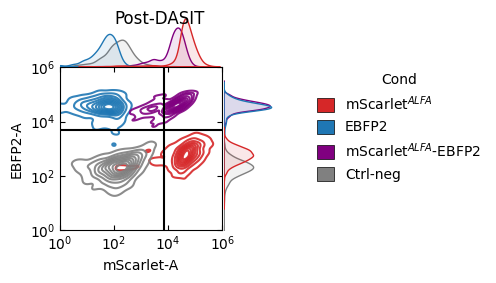

In [65]:
# General plotting params
x = "mScarlet-A"
y = "EBFP2-A"

hue = 'cond'
hue_order = ["mScarlet$^{ALFA}$", "EBFP2", "mScarlet$^{ALFA}$-EBFP2", "Ctrl-neg"]
# hue_order = ["EGFP"]
palette = {
    "mScarlet$^{ALFA}$": 'tab:red',
    'EBFP2': 'tab:blue',
    "mScarlet$^{ALFA}$-EBFP2": "purple",
    "mScarlet$^{ALFA}$-EBFP2-p53DD": "tab:orange",
    "Ctrl-neg": 'grey',
}

# Downsample df_OR for faster
small_df_AND = df_AND[(df_AND[x]>0) & (df_AND[y]>0)]
small_df_AND = small_df_AND.groupby(['cond', 'select']).sample(n=1000)

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = (1, 1e6)
xlim = (1, 1e6)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
select = "Post"

curr_df = small_df_AND[(small_df_AND['select']==select)]
small_df_AND = pd.concat([curr_df, small_df_AND[(small_df_AND['cond']=="Ctrl-neg")]])
sns.kdeplot(
    ax=ax_scatter,
    data=small_df_AND,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_df_AND, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=True,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_df_AND, y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# Remove any automatically generated legends
for a in [ax_scatter, ax_histx, ax_histy]:
    if a.get_legend() is not None:
        a.get_legend().remove()

# Create legend handles
legend_handles = [
    Patch(
        facecolor=palette[label],
        edgecolor='black',
        linewidth=0.5,
        label=label
    )
    for label in hue_order
]

# Leave room on the right for the legend
fig.subplots_adjust(right=0.82)

# Add legend outside the plot
ax_scatter.legend(
    handles=legend_handles,
    title='Cond',
    loc='upper left',
    bbox_to_anchor=(1.55, 1.0),
    frameon=False,
    borderaxespad=0,
    handlelength=1.2,
    handleheight=1.2
)

# Threshold
ax_scatter.axvline(mScarlet_A_thresh, 0, 1, color='black')
ax_scatter.axhline(EBFP2_A_thresh, 0, 1, color='black')

plt.suptitle(f'{select}-DASIT')

fig.tight_layout()  # Helps improve white spacing
plottitle = f'Figure_S7D_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')  

**Figure S7D, pre-DASIT**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs

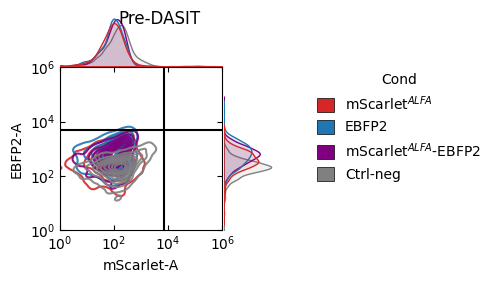

In [64]:
# General plotting params
x = "mScarlet-A"
y = "EBFP2-A"

hue = 'cond'
hue_order = ["mScarlet$^{ALFA}$", "EBFP2", "mScarlet$^{ALFA}$-EBFP2", "Ctrl-neg"]
# hue_order = ["EGFP"]
palette = {
    "mScarlet$^{ALFA}$": 'tab:red',
    'EBFP2': 'tab:blue',
    "mScarlet$^{ALFA}$-EBFP2": "purple",
    "mScarlet$^{ALFA}$-EBFP2-p53DD": "tab:orange",
    "Ctrl-neg": 'grey',
}

# Downsample df_OR for faster
small_df_AND = df_AND[(df_AND[x]>0) & (df_AND[y]>0)]
small_df_AND = small_df_AND.groupby(['cond', 'select']).sample(n=1000)

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = (1, 1e6)
xlim = (1, 1e6)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
select = "Pre"

curr_df = small_df_AND[(small_df_AND['select']==select)]
small_df_AND = pd.concat([curr_df, small_df_AND[(small_df_AND['cond']=="Ctrl-neg")]])
sns.kdeplot(
    ax=ax_scatter,
    data=small_df_AND,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_df_AND, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=True,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_df_AND, y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# Remove any automatically generated legends
for a in [ax_scatter, ax_histx, ax_histy]:
    if a.get_legend() is not None:
        a.get_legend().remove()

# Create legend handles
legend_handles = [
    Patch(
        facecolor=palette[label],
        edgecolor='black',
        linewidth=0.5,
        label=label
    )
    for label in hue_order
]

# Leave room on the right for the legend
fig.subplots_adjust(right=0.82)

# Add legend outside the plot
ax_scatter.legend(
    handles=legend_handles,
    title='Cond',
    loc='upper left',
    bbox_to_anchor=(1.55, 1.0),
    frameon=False,
    borderaxespad=0,
    handlelength=1.2,
    handleheight=1.2
)

# Threshold
ax_scatter.axvline(mScarlet_A_thresh, 0, 1, color='black')
ax_scatter.axhline(EBFP2_A_thresh, 0, 1, color='black')

plt.suptitle(f'{select}-DASIT')

fig.tight_layout()  # Helps improve white spacing
plottitle = f'Figure_S7D_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')  

## Figure S7 (Final plots for single distributions)

**Figure S7C, plot 1 and 2**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

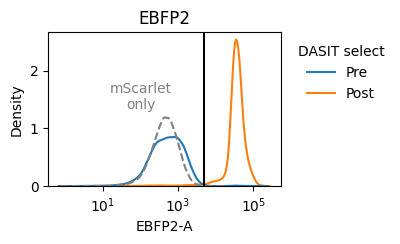

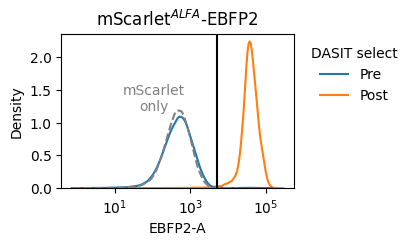

In [68]:
# Plotting parameters
x = 'EBFP2-A'
hue = 'select'
hue_order = ["Pre", "Post"]

# Plot
for cond in ["EBFP2", "mScarlet$^{ALFA}$-EBFP2"]:
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_AND[(df_AND[x]>0) & (df_AND['cond']==cond)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False),
                fill=False)

        # Plot neg
        sns.kdeplot(data=df_AND.loc[(df_AND['cond'] == 'mScarlet$^{ALFA}$') & (df_AND[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('mScarlet\nonly', (0.4, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(EBFP2_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{cond}')
        # Save existing Seaborn legend handles/labels
        leg = ax.get_legend()
        handles = leg.legend_handles
        labels = [text.get_text() for text in leg.get_texts()]

        # Remove existing legend
        leg.remove()

        # Recreate legend on right with line handles
        ax.legend(
                handles=handles,
                labels=labels,
                title='DASIT select',
                loc='upper left',
                bbox_to_anchor=(1.02, 1),
                frameon=False
        )

        plottitle = f'Figure_S7C_top_{cond}-DASIT.svg'
        plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight')   

**Figure S7C, plot 3 and 4**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

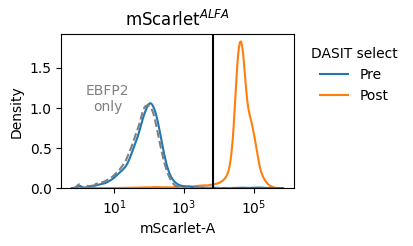

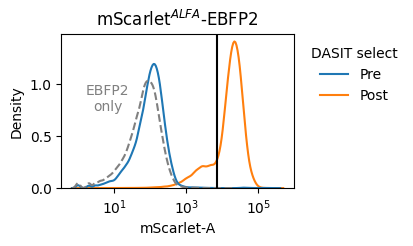

In [67]:
# Plotting parameters
x = 'mScarlet-A'
hue = 'select'
hue_order = ["Pre", "Post"]

# Plot
for cond in ["mScarlet$^{ALFA}$", "mScarlet$^{ALFA}$-EBFP2"]:
        fig, ax = plt.subplots(1, 1, figsize=(3, 2))
        sns.kdeplot(data=df_AND[(df_AND[x]>0) & (df_AND['cond']==cond)],
                ax=ax, x=x, hue=hue, hue_order=hue_order,
                common_norm=False, log_scale=(True, False),
                fill=False)

        sns.kdeplot(data=df_AND.loc[(df_AND['cond'] == 'EBFP2') & (df_AND[x]>0)],
                ax=ax, x=x,
                common_norm=False, log_scale=(True, False),
                fill=False, linestyle='--', color='grey')
        ax.annotate('EBFP2\nonly', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

        # Plot threshold
        ax.axvline(mScarlet_A_thresh, 0, 1, color='black')

        # Format
        plt.title(f'{cond}')
        # Save existing Seaborn legend handles/labels
        leg = ax.get_legend()
        handles = leg.legend_handles
        labels = [text.get_text() for text in leg.get_texts()]

        # Remove existing legend
        leg.remove()


        # Recreate legend on right with line handles
        ax.legend(
                handles=handles,
                labels=labels,
                title='DASIT select',
                loc='upper left',
                bbox_to_anchor=(1.02, 1),
                frameon=False
        )

        plottitle = f'Figure_S7C_bottom_{cond}-DASIT.svg'
        plt.savefig(rd.outfile(output_path_FigureS7/plottitle),bbox_inches='tight') 

## Figure 3 (Stacked barchats, AND)

In [73]:
# CategANDize cells 
df_AND['mScarlet_cat'] = np.where(df_AND['mScarlet-A'] > mScarlet_A_thresh, 'mScarlet+', 'mScarlet-') 
df_AND['EBFP2_cat'] = np.where(df_AND['EBFP2-A'] > EBFP2_A_thresh, 'EBFP2+', 'EBFP2-') 

df_AND.loc[(df_AND['mScarlet_cat'] == 'mScarlet+') & (df_AND['EBFP2_cat'] == 'EBFP2+'), 'FP_cat' ] = 'Both'
df_AND.loc[(df_AND['mScarlet_cat'] == 'mScarlet+') & (df_AND['EBFP2_cat'] == 'EBFP2-'), 'FP_cat' ] = "mScarlet$^{ALFA}$"
df_AND.loc[(df_AND['mScarlet_cat'] == 'mScarlet-') & (df_AND['EBFP2_cat'] == 'EBFP2+'), 'FP_cat' ] = 'EBFP2'
df_AND.loc[(df_AND['mScarlet_cat'] == 'mScarlet-') & (df_AND['EBFP2_cat'] == 'EBFP2-'), 'FP_cat' ] = 'Neg'

# Get total counts and percent of GFP-H+
group = ['cond', 'select']
count_df_reps = df_AND.groupby([*group, 'rep', 'FP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
# Puts 0 if no GFP-H+ rather than dropping row
df_AND_percent_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'rep']).transform('sum')).reset_index(name='percent')


# Drop p53DD
df_AND_percent_reps = df_AND_percent_reps[df_AND_percent_reps.cond != "mScarlet$^{ALFA}$-EBFP2-p53DD"]

# Collapse reps
df_AND_percent_mean = df_AND_percent_reps.groupby([*group, 'FP_cat']).mean().reset_index()
df_AND_percent_sem = df_AND_percent_reps.groupby([*group, 'FP_cat']).sem().reset_index()


**Figure 3C, pre-DASIT**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\4216650764.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')


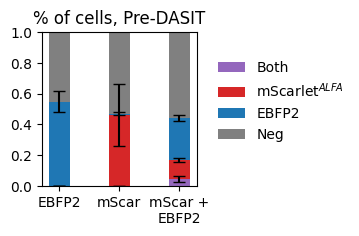

In [74]:
# Plot params
width = 0.35       # the width of the bars: can also be len(x) sequence
capsize = 4        # Capsize
label_dict = {
    "mScarlet$^{ALFA}$": 'mScar',
    'EBFP2': 'EBFP2',
    "mScarlet$^{ALFA}$-EBFP2": "mScar +\nEBFP2",
    "mScarlet$^{ALFA}$-EBFP2-p53DD":"mScar +\nEBFP2 +\np53DD",
}

# Extract each mean and SEM
select = 'Pre'
curr_mean = df_AND_percent_mean[df_AND_percent_mean.select == select]
curr_sem = df_AND_percent_sem[df_AND_percent_sem.select == select]
# Drop Ctrl-neg
curr_mean = curr_mean[curr_mean.cond != "Ctrl-neg"]
curr_sem = curr_sem[curr_sem.cond != "Ctrl-neg"]

FP_cat = 'Both'
labels = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'cond']
both_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
both_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = "mScarlet$^{ALFA}$"
mScarlet_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
mScarlet_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'EBFP2'
EEBFP2_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
EBFP2_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'Neg'
Neg_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
Neg_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax.bar(labels, both_mean, width, yerr=both_sem, label='Both', color='tab:purple', capsize=capsize)
ax.bar(labels, mScarlet_mean, width, yerr=mScarlet_sem, bottom=both_mean, label="mScarlet$^{ALFA}$", color='tab:red', capsize=capsize)
ax.bar(labels, EEBFP2_mean, width, yerr=EBFP2_sem, bottom=both_mean.to_numpy()+mScarlet_mean.to_numpy(), label='EBFP2', color='tab:blue', capsize=capsize)
ax.bar(labels, Neg_mean, width, yerr=Neg_sem, bottom=both_mean.to_numpy()+mScarlet_mean.to_numpy()+EEBFP2_mean.to_numpy(), label='Neg', color='grey', capsize=capsize)

# # Add 100% line
ax.set_ylim([0, 1])
# ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Rename axis labels
ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')
# ax.set_ylabel('(%)')
plt.title(f'% of cells, {select}-DASIT')
fig.legend(loc='upper right', bbox_to_anchor=(1.7, 0.8), frameon=False)

plottitle = f'Figure_S3C_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_Figure3/plottitle),bbox_inches='tight')  

**Figure 3C, post-DASIT**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\3969490075.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')


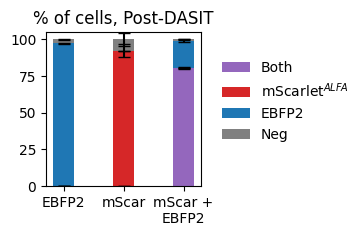

In [75]:
# Plot params
width = 0.35       # the width of the bars: can also be len(x) sequence
capsize = 4        # Capsize
label_dict = {
    "mScarlet$^{ALFA}$": "mScar",
    'EBFP2': 'EBFP2',
    "mScarlet$^{ALFA}$-EBFP2": "mScar +\nEBFP2",
    "mScarlet$^{ALFA}$-EBFP2-p53DD":"mScar +\nEBFP2 +\np53DD",
    "Ctrl-neg": 'Neg'
}

# Extract each mean and SEM
select = 'Post'
curr_mean = df_AND_percent_mean[df_AND_percent_mean.select == select]
curr_sem = df_AND_percent_sem[df_AND_percent_sem.select == select]
# Drop Ctrl-neg
curr_mean = curr_mean[curr_mean.cond != "Ctrl-neg"]
curr_sem = curr_sem[curr_sem.cond != "Ctrl-neg"]

FP_cat = 'Both'
labels = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'cond']
both_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
both_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = "mScarlet$^{ALFA}$"
mScarlet_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
mScarlet_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'EBFP2'
EEBFP2_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
EBFP2_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

FP_cat = 'Neg'
Neg_mean = curr_mean.loc[(curr_mean['FP_cat'] == FP_cat), 'percent']
Neg_sem = curr_sem.loc[(curr_sem['FP_cat'] == FP_cat), 'percent']

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2,2))
ax.bar(labels, both_mean, width, yerr=both_sem, label='Both', color='tab:purple', capsize=capsize)
ax.bar(labels, mScarlet_mean, width, yerr=mScarlet_sem, bottom=both_mean, label="mScarlet$^{ALFA}$", color='tab:red', capsize=capsize)
ax.bar(labels, EEBFP2_mean, width, yerr=EBFP2_sem, bottom=both_mean.to_numpy()+mScarlet_mean.to_numpy(), label='EBFP2', color='tab:blue', capsize=capsize)
ax.bar(labels, Neg_mean, width, yerr=Neg_sem, bottom=both_mean.to_numpy()+mScarlet_mean.to_numpy()+EEBFP2_mean.to_numpy(), label='Neg', color='grey', capsize=capsize)

# # Add 100% line
ax.set_ylim([0, 105])
# ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Rename axis labels
ax.xaxis.set_ticklabels([label_dict[l] for l in labels], horizontalalignment='center')
# ax.set_ylabel('(%)')
plt.title(f'% of cells, {select}-DASIT')
fig.legend(loc='upper right', bbox_to_anchor=(1.7, 0.8), frameon=False)

plottitle = f'Figure_S3C_{select}-DASIT.svg'
plt.savefig(rd.outfile(output_path_Figure3/plottitle),bbox_inches='tight')  

# Integration

## Figure S5 integration

In [76]:
# Directories
df_int_dir = rd.datadir /'data'/'attune'/'Albert'/'DesNb'/ "Integration" / "2025.12.11-_iPS11-CAG-BFP-mR2_Pre" / "export_singlets"

# Store all df_OR in list of dfs which will be converted to df at end
df_int = list()
# ctrl_df_OR = list()
files = Path(df_int_dir).glob('*.csv')

# df_OR path
cache_path = df_int_dir / 'df_int.gzip'

if cache_path.exists():

    df_int = pd.read_parquet(cache_path)

else: 

    for i, file in enumerate(files):

        print(file.name)

        # Extract metadf_OR from csv title
        match = re.search(
            'export_(?P<cond>.+)_(?P<subsetName>.+).csv', file.name)
        
        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        subsetName = match.group('subsetName')

        # Load as df and note header is on 0th row
        flow_df = pd.read_csv(file, header=0)

        # Update columns in df with metadf_OR from file name
        flow_df['cond'] = cond
        flow_df['subsetName'] = subsetName
        
        df_int.append(flow_df)

    # Convert list of dfs into single df
    df_int = pd.concat(df_int, ignore_index=True)

    # Shorten df
    channel_list = ['FSC-A', 'SSC-A', 'mScarlet-A','mScarlet-H', 'cond', 'subsetName']
    df_int = df_int.loc[:, channel_list]
    # Rename FP channels
    df_int.rename(columns={'mScarlet-A': 'mRuby2-A', 'mScarlet-H': 'mRuby2-H'}, inplace=True)

    # Save shortened df
    df_int.to_parquet(rd.outfile(cache_path))


In [77]:
display(df_int)

,FSC-A,SSC-A,mRuby2-A,mRuby2-H,cond,subsetName
0,532871,290271,13716,8691,Post,Singlets
1,437720,156863,12852,8359,Post,Singlets
2,743714,222777,18146,8937,Post,Singlets
3,405952,139103,4240,2933,Post,Singlets
4,423419,109354,8561,6210,Post,Singlets
...,...,...,...,...,...,...
26341,647131,686217,322,143,Parental,Singlets
26342,389273,157393,37,81,Parental,Singlets
26343,409812,178287,-83,50,Parental,Singlets
26344,443565,187012,170,97,Parental,Singlets


c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(10, 100000.0)

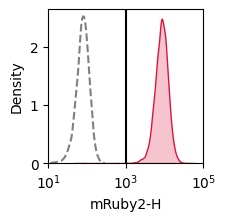

In [78]:
# Threshold for transfect
mRuby2_H_thresh = 1e3

# Plotting parameters
x = 'mRuby2-H'
hue = 'cond'

# Plot post-integration
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
sns.kdeplot(data=df_int[(df_int[x]>0) & (df_int['cond']=='Post')],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='Crimson',
        fill=True)

# Plot parental
sns.kdeplot(data=df_int.loc[(df_int['cond'] == 'Parental') & (df_int[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')

# Plot threshold
ax.axvline(mRuby2_H_thresh, 0, 1, color='black')
ax.set_xlim((10, 1e5))

In [79]:
# Categorize cells 
df_int['mRuby2_cat'] = np.where(df_int['mRuby2-H'] > mRuby2_H_thresh, 'mRuby2+', 'mRuby2-') 

# Get total counts and percent of GFP-H+
group = ['cond']
count_df_reps = df_int.groupby([*group, 'mRuby2_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
# count_df_reps = df_AND.groupby([*group, 'mScarlet_cat', 'EBFP2_cat'])[
#     'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
df_int_percent = (count_df_reps*100/count_df_reps.groupby([*group]).transform('sum')).reset_index(name='percent')

**Figure S5C plot**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_2476\2475625135.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mRuby2_percent = float(df_int_percent[(df_int_percent.cond == 'Post') & (df_int_percent.mRuby2_cat == 'mRuby2+')]['percent'])
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


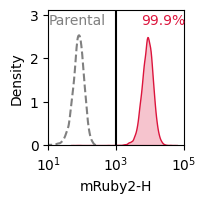

In [82]:
# Threshold for transfect
mRuby2_H_thresh = 1e3

# Plotting parameters
x = 'mRuby2-H'
hue = 'cond'

# Plot post-integration
fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75))
sns.kdeplot(data=df_int[(df_int[x]>0) & (df_int['cond']=='Post')],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='Crimson',
        fill=True)
# Percentage
mRuby2_percent = float(df_int_percent[(df_int_percent.cond == 'Post') & (df_int_percent.mRuby2_cat == 'mRuby2+')]['percent'])
ax.annotate(f'{mRuby2_percent:0.1f}%', (0.85, 0.9), color='crimson', xycoords='axes fraction', ha='center')

# Plot parental
sns.kdeplot(data=df_int.loc[(df_int['cond'] == 'Parental') & (df_int[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate(f'Parental', (0, 0.9), color='grey', xycoords='axes fraction', ha='left')


# Plot threshold
ax.axvline(mRuby2_H_thresh, 0, 1, color='black')
ax.set_xlim((10, 1e5))
ax.set_ylim((0,3.1))
# ax.set_xlabel('mRuby2')

# Format
plottitle = f'Figure_S5C_integration.svg'
plt.savefig(rd.outfile(output_path_FigureS5/plottitle),bbox_inches='tight')  

## Figure S8 integration

In [83]:
# Directories
df_int_dir = rd.datadir / 'data'/'attune'/'Albert'/'DesNb'/ "Integration" / "2025.12.21_iPSC11-Dual-mGL-iRFP670" / "export_singlets"

# Store all df_OR in list of dfs which will be converted to df at end
df_int_2 = list()
# ctrl_df_OR = list()
files = Path(df_int_dir).glob('*.csv')

# df_OR path
cache_path = df_int_dir / 'df_int_2.gzip'

if cache_path.exists():

    df_int_2 = pd.read_parquet(cache_path)

else: 

    for i, file in enumerate(files):

        print(file.name)

        # Extract metadf_OR from csv title
        match = re.search(
            'export_(?P<cond>.+)_(?P<subsetName>.+).csv', file.name)
        
        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        subsetName = match.group('subsetName')

        # Load as df and note header is on 0th row
        flow_df = pd.read_csv(file, header=0)

        # Update columns in df with metadf_OR from file name
        flow_df['cond'] = cond
        flow_df['subsetName'] = subsetName
        
        df_int_2.append(flow_df)

    # Convert list of dfs into single df
    df_int_2 = pd.concat(df_int_2, ignore_index=True)

    # Shorten df
    channel_list = ['FSC-A', 'SSC-A', 'mGreenLantern-A','iRFP670-A', 'cond', 'subsetName']
    df_int_2 = df_int_2.loc[:, channel_list]

    # Save shortened df
    df_int_2.to_parquet(rd.outfile(cache_path))


In [84]:
display(df_int_2)

,FSC-A,SSC-A,mGreenLantern-A,iRFP670-A,cond,subsetName
0,566542,197174,11063,30441,mGL-iRFP670,Gated
1,605409,205036,16195,39627,mGL-iRFP670,Gated
2,616330,210827,14123,34651,mGL-iRFP670,Gated
3,451334,216953,5831,16752,mGL-iRFP670,Gated
4,511930,360732,9418,27840,mGL-iRFP670,Gated
...,...,...,...,...,...,...
6957,489210,192358,134,99,negative,Gated
6958,473868,373361,124,46,negative,Gated
6959,499456,271616,69,101,negative,Gated
6960,427490,211875,151,9,negative,Gated


**Figure S8C**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs

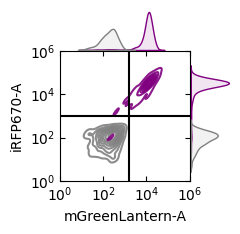

In [85]:
# General plotting params
x = "mGreenLantern-A"
y = "iRFP670-A"

hue = 'cond'
hue_order = ["negative", "mGL-iRFP670"]

palette = {
    'mGL-iRFP670': 'purple',
    "negative": 'grey',
}

# Downsample df_OR for faster
small_df_int = df_int_2[(df_int_2[x]>0) & (df_int_2[y]>0)]
small_df_int = small_df_int.groupby(['cond']).sample(n=1000, random_state=5)

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2, 2))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = (1, 1e6)
xlim = (1, 1e6)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots

sns.kdeplot(
    ax=ax_scatter,
    data=small_df_int,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_df_int, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_df_int,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)


# Threshold
iRFP670_A_thresh = 1e3
mGL_A_thresh = 1.5e3
ax_scatter.axvline(mGL_A_thresh, 0, 1, color='black')
ax_scatter.axhline(iRFP670_A_thresh, 0, 1, color='black')

# fig.tight_layout()  # Helps improve white spacing
plottitle = f'Figure_S8C_integration.svg'
plt.savefig(rd.outfile(output_path_FigureS8/plottitle),bbox_inches='tight')  

In [60]:
# Categorize cells 
df_int_2['mGL_cat'] = np.where(df_int_2['mGreenLantern-A'] > mGL_A_thresh, 'mGL+', 'mGL-') 
df_int_2['iRFP670_cat'] = np.where(df_int_2['iRFP670-A'] > iRFP670_A_thresh, 'iRFP670+', 'iRFP670-') 
df_int_2.loc[:, 'FP_cat' ] = 'neg'
df_int_2.loc[(df_int_2['mGL_cat'] == 'mGL+') & (df_int_2['iRFP670_cat'] == 'iRFP670+'), 'FP_cat' ] = 'Both'

# Get total counts and percent of GFP-H+
group = ['cond']
count_df = df_int_2.groupby([*group, 'FP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
df_percent = (count_df*100/count_df.groupby([*group]).transform('sum')).reset_index(name='percent')

df_percent

,cond,FP_cat,percent
0,mGL-iRFP670,Both,94.921664
1,mGL-iRFP670,neg,5.078336
2,negative,Both,0.000000
3,negative,neg,100.000000
